Exploring graph tools package using auditory connectome: https://graph-tool.skewed.de/static/docs/stable/quickstart.html

In [1]:
from graph_tool.all import *

In [7]:
g = Graph()

In [8]:
v1 = g.add_vertex()
v2 = g.add_vertex()

In [9]:
e = g.add_edge(v1, v2)

In [16]:
eweight = g.new_ep("double")    # creates an EdgePropertyMap of type double
vcolor = g.new_vp("string")     # creates a VertexPropertyMap of type string

eweight[e] = 125.5
vcolor[v1] = "#1c71d8"
vcolor[v2] = "#2ec27e"

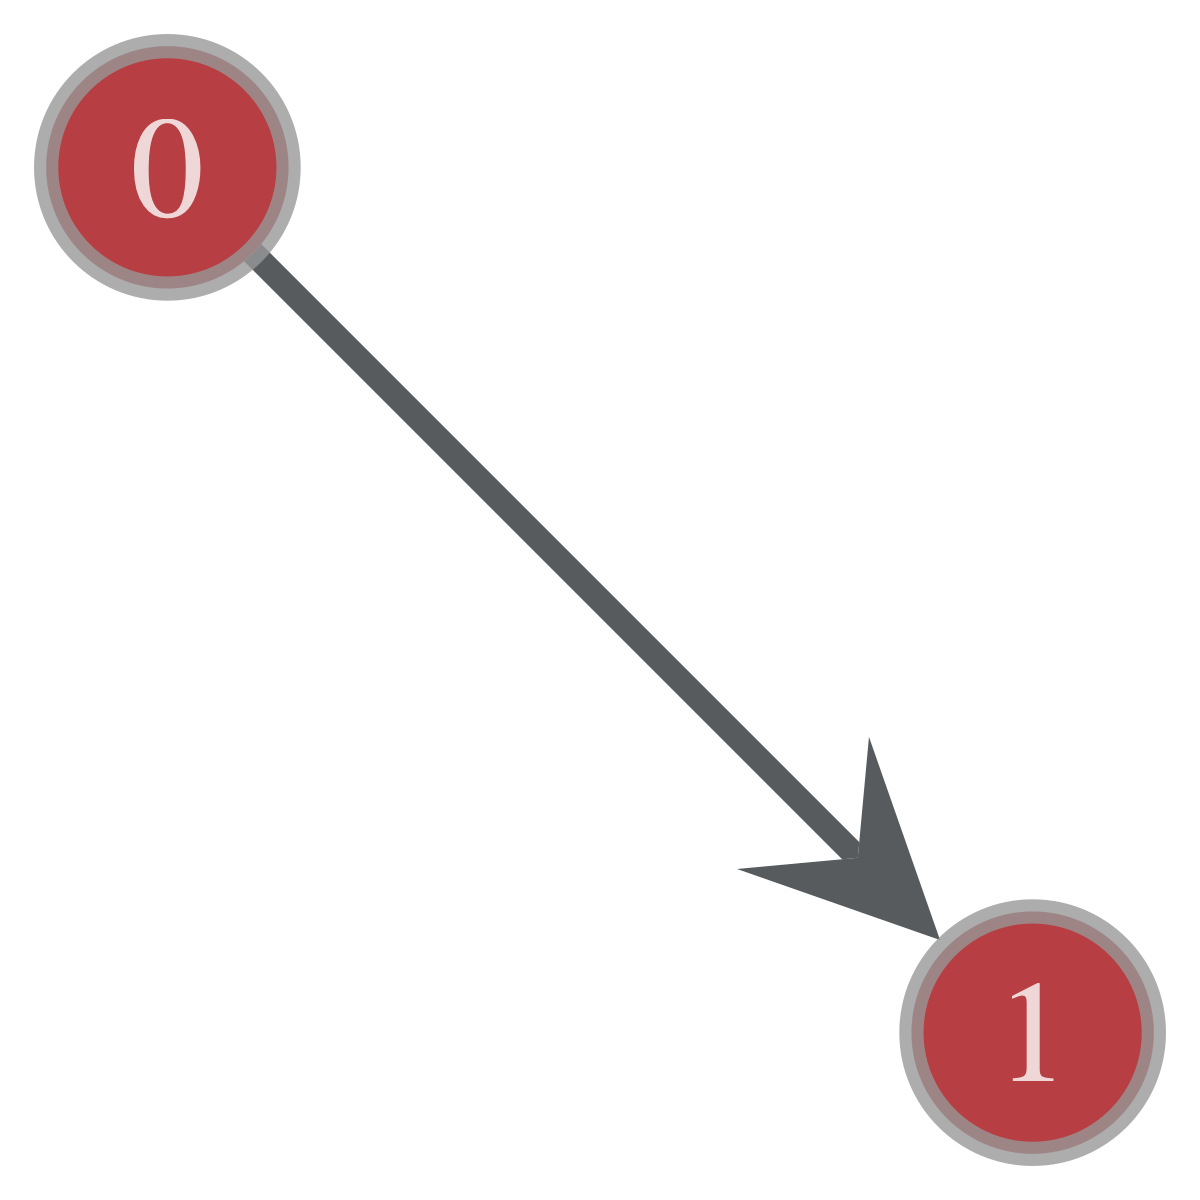

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x17fab8690, at 0x316aba200>

In [17]:
graph_draw(g, vertex_text=g.vertex_index)#, vertex_font_size=18, output_size=(200, 200), output="two_vertices.png")

In [18]:
g = Graph([('foo', 'bar', .5, 1), ('gnu', 'gnat', .78, 2)], hashed=True,
          eprops=[('weight', 'double'), ('time', 'int')])

In [20]:
g = Graph({0: [2, 3], 1: [4], 3: [4, 5], 6: []})

In [25]:
import numpy as np
import scipy

m = np.array([[0, 1.2, 0],
              [0, 0, 10],
              [0, 7, 0]])
g = Graph(scipy.sparse.lil_matrix(m))
print(g.ep.weight.a)

[ 1.2  7.  10. ]


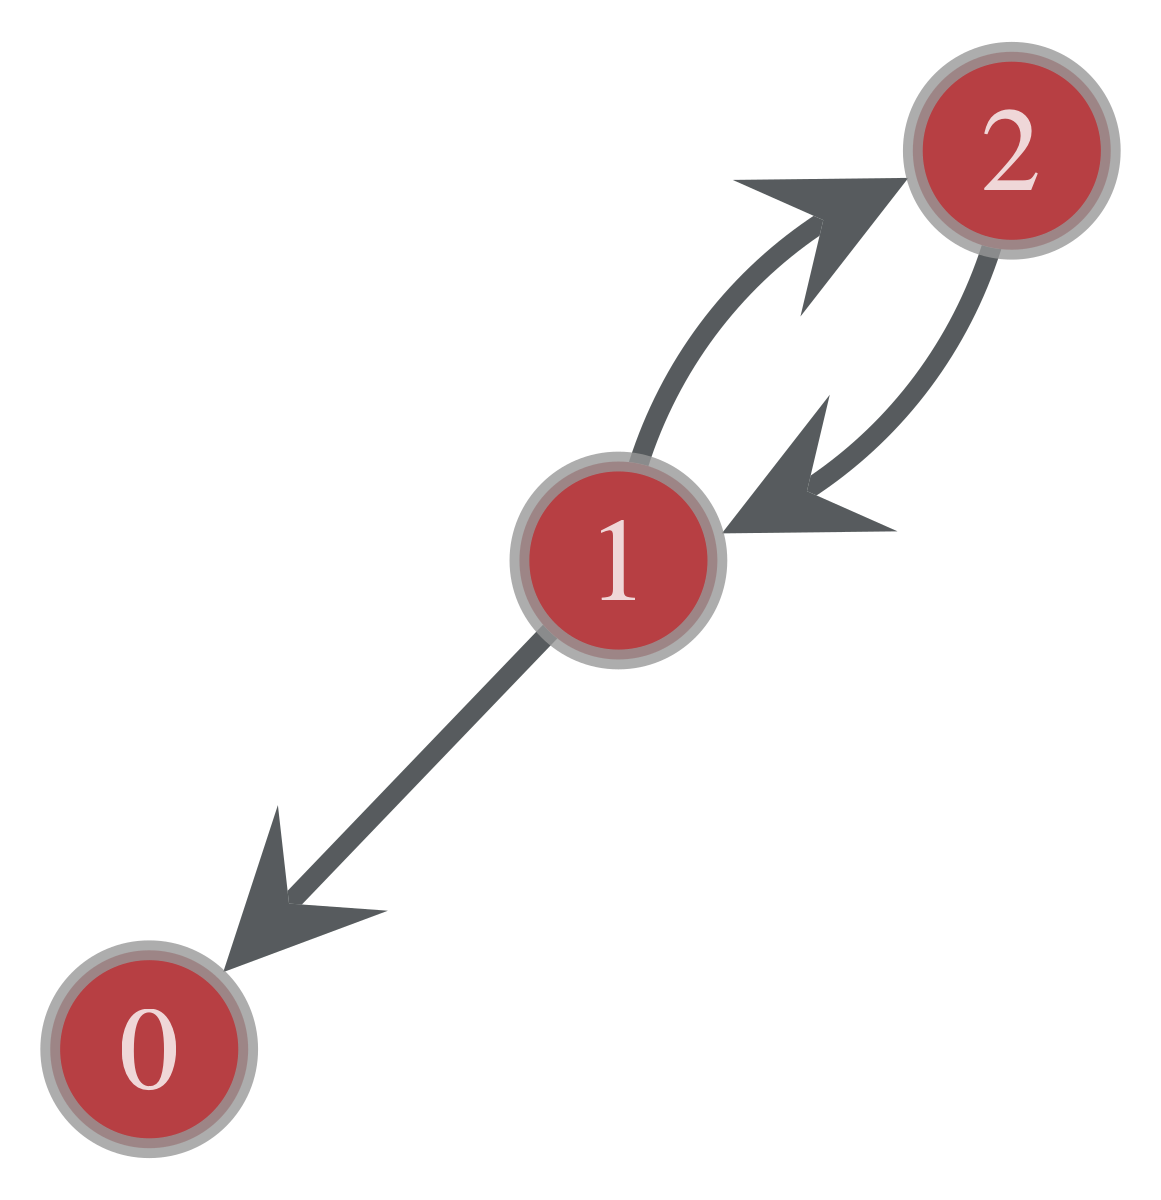

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x17fabb610, at 0x316abb1c0>

In [26]:
graph_draw(g, vertex_text=g.vertex_index)

In [29]:
for v in g.vertices():
    print(v)

0
1
2


In [31]:
for v in g.vertices():
   for e in v.out_edges():
       print(e)

(1, 0)
(1, 2)
(2, 1)


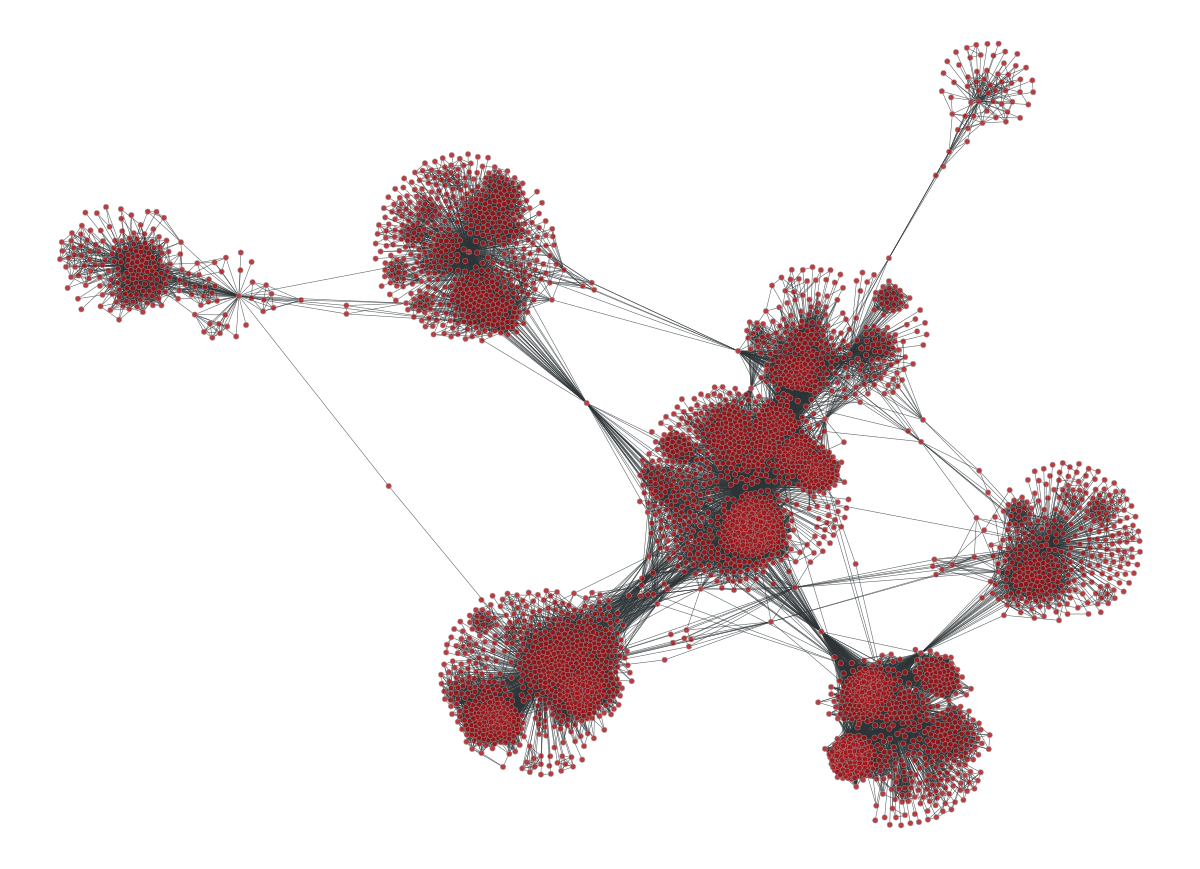

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x17fabb390, at 0x316ababa0>

In [32]:
g = collection.ns["ego_social/facebook_combined"]
graph_draw(g, g.vp._pos)

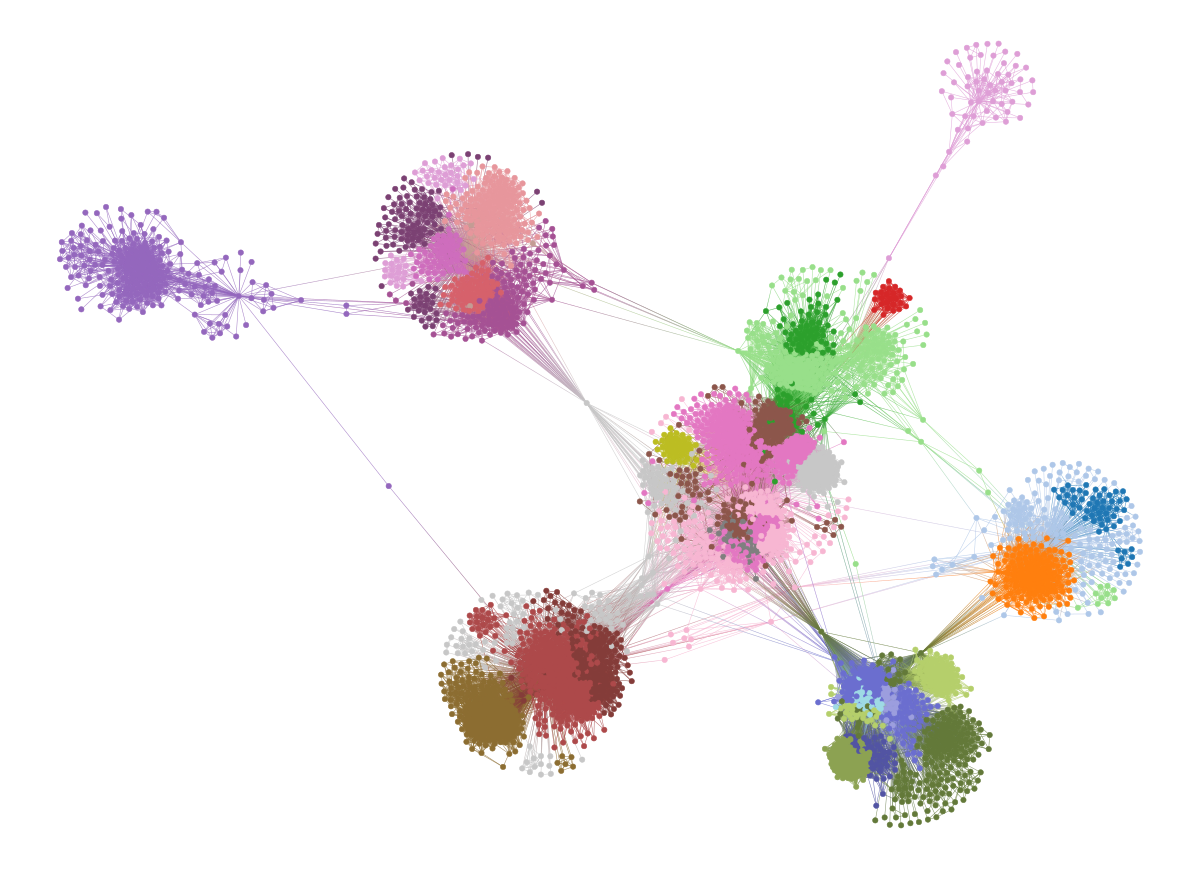

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x17fabb390, at 0x320c08b40>

In [33]:
state = minimize_blockmodel_dl(g)
state.draw(pos=g.vp._pos)

In [35]:
vb, eb = betweenness(g)
print(vb.a)

[1.46305921e-01 2.78327442e-06 7.59502118e-08 ... 0.00000000e+00
 7.15684688e-08 6.33892152e-07]


# Working with connectome data

In [37]:
import pandas as pd
import numpy as np
import json

In [39]:
_auditory_neuron_conns = pd.read_csv("auditory_neuron_connections.csv.gz", compression='gzip')

auditory_neuron_conns = _auditory_neuron_conns.rename(columns={"Unnamed: 0": "index_in_connections_table"})

with open("unique_neuron_ids.json", "r") as f:
    unique_ids = json.load(f)

In [38]:
# Some auditory neurons with selectivity labels provided by Ian from Sama's lab
train_dat = pd.read_csv("data/train_dat.csv")
train_dat

,Unnamed: 0,Flywire 2024 ID,Neuropils,preference,# imaged females,# responding females,prop females with auditory responses
0,0,720575940619783518,AVLP_pr01,sine,4,4,1.000000
1,1,720575940620062633,AVLP_pr01,sine,4,4,1.000000
2,2,720575940602914988,AVLP_pr01,sine,4,4,1.000000
3,3,720575940620195719,AVLP_pr01,sine,4,4,1.000000
4,4,720575940634508174,AVLP_pr01,sine,4,4,1.000000
...,...,...,...,...,...,...,...
398,398,720575940655398817,GNG_pr01,sine,17,4,0.235294
399,399,720575940630203589,GNG_pr01,sine,17,4,0.235294
400,400,720575940617641077,GNG_pr01,sine,17,4,0.235294
401,401,720575940612801022,GNG_pr01,sine,17,4,0.235294


In [ ]:
# get connections only for tuned neurons in train_dat
tuned_neurons = train_dat["Flywire 2024 ID"]
tuned_neuron_conns = auditory_neuron_conns[auditory_neuron_conns["pre_root_id"].isin(tuned_neurons) & auditory_neuron_conns["post_root_id"].isin(tuned_neurons)]

In [48]:
# get connections only for tuned neurons in train_dat
test_neurons = train_dat[train_dat["Neuropils"]=='AVLP_pr18']["Flywire 2024 ID"]
test_neuron_conns = auditory_neuron_conns[auditory_neuron_conns["pre_root_id"].isin(test_neurons) & auditory_neuron_conns["post_root_id"].isin(test_neurons)]
test_neuron_conns

,index_in_connections_table,pre_root_id,post_root_id,neuropil,syn_count,nt_type
105,421,720575940630302551,720575940630396790,AVLP_R,16,SER
29311,135391,720575940632109775,720575940616941201,AVLP_L,1,GLUT
147246,801110,720575940630396790,720575940630302551,PVLP_L,2,ACH
157236,857740,720575940616941201,720575940632109775,AVLP_R,1,GABA
233637,1287273,720575940630302551,720575940630396790,PVLP_R,2,ACH
316302,1752789,720575940630396790,720575940630302551,AVLP_R,1,ACH
345553,1917895,720575940630302551,720575940630396790,AVLP_L,2,GLUT
349935,1942583,720575940630396790,720575940630302551,AVLP_L,24,ACH
399092,2219250,720575940632109775,720575940616941201,AVLP_R,2,GLUT
472984,2637371,720575940630396790,720575940630302551,PVLP_R,1,ACH


In [49]:
test_neurons

283    720575940616941201
284    720575940632109775
285    720575940630396790
286    720575940630302551
Name: Flywire 2024 ID, dtype: int64

In [50]:
conns = test_neuron_conns[["pre_root_id", "post_root_id"]].to_numpy()
conns

array([[720575940630302551, 720575940630396790],
       [720575940632109775, 720575940616941201],
       [720575940630396790, 720575940630302551],
       [720575940616941201, 720575940632109775],
       [720575940630302551, 720575940630396790],
       [720575940630396790, 720575940630302551],
       [720575940630302551, 720575940630396790],
       [720575940630396790, 720575940630302551],
       [720575940632109775, 720575940616941201],
       [720575940630396790, 720575940630302551],
       [720575940616941201, 720575940632109775],
       [720575940630302551, 720575940630396790]])

In [1]:
g = Graph()
g.add_vertex(list(test_neurons))

NameError: name 'Graph' is not defined

In [ ]:
graph_draw(g, vertex_text=g.vertex_index)